# Exercise 1 — Logistic Regression

## Part A: Understanding Logistic Regression

Imagine we want to predict whether a student will pass an exam.

For each student, we know:

* the number of study hours
* whether the student passed or failed

Our goal is to predict: `pass (1) or fail (0)`

Unlike linear regression, logistic regression predicts a probability between 0 and 1.

### Logistic Regression Model

The model is:

`z = weight × x + bias`

Then we apply the sigmoid function:

`p = 1 / (1 + e^(-z))`

Where:

* x = input feature (study hours)
* weight = importance of the feature
* bias = shifts the curve
* p = probability of passing

### Decision Rule

After computing the probability:

`if p > 0.5 → predict PASS

else → predict FAIL`

Your Task

Change the values of: `weight` and `bias` as in previous exercises.

until the sigmoid curve separates the two classes as well as possible.

Try to understand:

* what the weight changes
* what the bias changes
* where the decision boundary appears

### Sample Student Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# x = study hours
x = np.array([0,1,2,3,4,5,6,7,8,9])

# y = fail(0) or pass(1)
y = np.array([0,0,0,0,0,1,1,1,1,1])

In [24]:
weight = 10
bias = -45

### Logistic Regression Predictions

In [25]:
# Linear part
z = weight * x + bias

# Sigmoid
p = 1 / (1 + np.exp(-z))

# Predicted classes
y_pred = (p > 0.5).astype(int)

### Plot the model

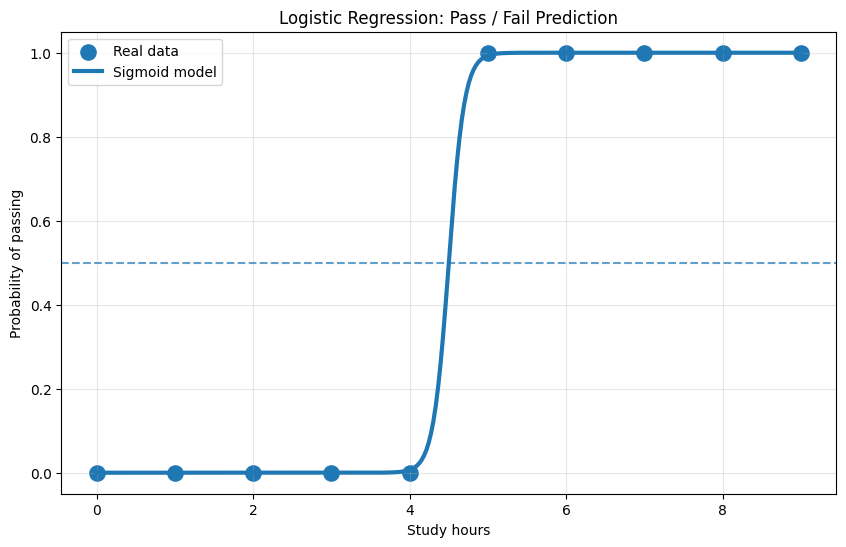

In [26]:
plt.figure(figsize=(10,6))

# Real data
plt.scatter(x, y, s=120, label="Real data")

# Smooth sigmoid curve
x_curve = np.linspace(0, 9, 300)
z_curve = weight * x_curve + bias
p_curve = 1 / (1 + np.exp(-z_curve))

plt.plot(x_curve, p_curve, linewidth=3, label="Sigmoid model")

# Decision threshold
plt.axhline(0.5, linestyle="--", alpha=0.7)

plt.xlabel("Study hours")
plt.ylabel("Probability of passing")
plt.title("Logistic Regression: Pass / Fail Prediction")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

Questions

1. What does the weight control?
2. What does the bias control?
3. What happens when the sigmoid becomes steeper?
4. Where is the decision boundary?
5. Which students are difficult to classify?
6. Why is logistic regression better than linear regression here?

Answer
1. The weight(w) determines the steep of the sigmoid curve and how confident the model is near the boundry.
2. The bias(b) shifts the curve left or right along x-axis, indepently of the input.
3. The model appears to be more confident when the sigmoid is steeper
4. The decision boundry is held at the middle of the plot, at around x=4.5-5.0
5. Those students that close to the decision boundry are the hardest to classify -> Meaning the model is uncertain to the decide which class they belong to.
6. The data is binary, the pattern is nonlinear, and the output must be a probability. Linear regression satisfies none of these. Logistic regression satisfies all three.

## Part B — Use a Real Dataset

Now repeat the same process using a real dataset.

Choose:

- one numerical column as `x`
- one binary column as `y`

Below are beginner-friendly datasets you can use.

| Dataset | Link | Example `x` | Example `y` | Task |
|---|---|---|---|---|
| Titanic | [Open dataset](https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv) | `Age`, `Fare` | `Survived` | Predict survival |
| Breast Cancer Wisconsin | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) | `mean radius`, `mean texture` | `target` | Benign vs malignant |
| Heart Disease | [Open dataset](https://archive.ics.uci.edu/dataset/45/heart+disease) | `cholesterol`, `age` | `disease` | Predict heart disease |
| Palmer Penguins | [Open dataset](https://github.com/allisonhorst/palmerpenguins) | `bill_length_mm`, `body_mass_g` | species converted to binary | Classify penguin species |
| Student Performance | [Open dataset](https://archive.ics.uci.edu/dataset/320/student+performance) | `studytime`, `absences` | pass/fail from final grade | Predict pass/fail |
| SMS Spam | [Open dataset](https://archive.ics.uci.edu/dataset/228/sms+spam+collection) | message length, number of keywords | spam / ham | Spam detection |

### Suggested choice 

Use the **Titanic dataset** first:

In [34]:
import pandas as pd


url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Your Real-Data Task

1. Load the dataset.
2. Display the first rows with df.head().
3. Choose one feature x.
4. Choose one binary target y.
5. Plot the data.
6. Try different values of weight and bias.
7. Observe how the sigmoid changes.
8. Compare your intuition with Python’s logistic regression model.

### Answer

In [74]:
# Load the dataset and display the first row 

import pandas as pd
from palmerpenguins import load_penguins

df = load_penguins()
df.head(1)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007


In [98]:
#Chose the feature x and y

import matplotlib.pyplot as plt

nume_feats = ["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]
bina_feats = ["species","sex"]

df_clean = df.dropna(subset=nume_feats + ["sex", "species"])

X = df_clean[nume_feats]

# Two binary targets
df_clean["sex_binary"]     = (df_clean["sex"] == "male").astype(int)     
df_clean["species_binary"] = (df_clean["species"] == "Adelie").astype(int)

y = df_clean["species_binary"]
print(x.head(10))
print()
print(y.head(10))


   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
0            39.1           18.7              181.0       3750.0
1            39.5           17.4              186.0       3800.0
2            40.3           18.0              195.0       3250.0
3             NaN            NaN                NaN          NaN
4            36.7           19.3              193.0       3450.0
5            39.3           20.6              190.0       3650.0
6            38.9           17.8              181.0       3625.0
7            39.2           19.6              195.0       4675.0
8            34.1           18.1              193.0       3475.0
9            42.0           20.2              190.0       4250.0

0     1
1     1
2     1
4     1
5     1
6     1
7     1
12    1
13    1
14    1
Name: species_binary, dtype: int64


In [111]:
nume_feats = ["bill_length_mm"]
#"bill_depth_mm", "flipper_length_mm", "body_mass_g"

# Drop missing values
df_clean = df.dropna(subset=nume_feats + ["sex", "species"])

# Binary targets
df_clean["sex_binary"]     = (df_clean["sex"] == "male").astype(int)
df_clean["species_binary"] = (df_clean["species"] == "Adelie").astype(int)

# Features and target
X = df_clean[nume_feats]
y = df_clean["species_binary"]  # or sex_binary

# Train
model = LogisticRegression()
model.fit(X, y)

# Weights (one per feature) and bias
for feat, w in zip(nume_feats, model.coef_[0]):
    print(f"weight ({feat}): {w:.4f}")
print(f"bias: {model.intercept_[0]:.4f}")

# Extract for plotting
weight = model.coef_[0][0]
bias = model.intercept_[0]
print(f"Decision boundary at x = {-bias/weight:.2f} mm")

weight (bill_length_mm): -1.1431
bias: 49.0169
Decision boundary at x = 42.88 mm


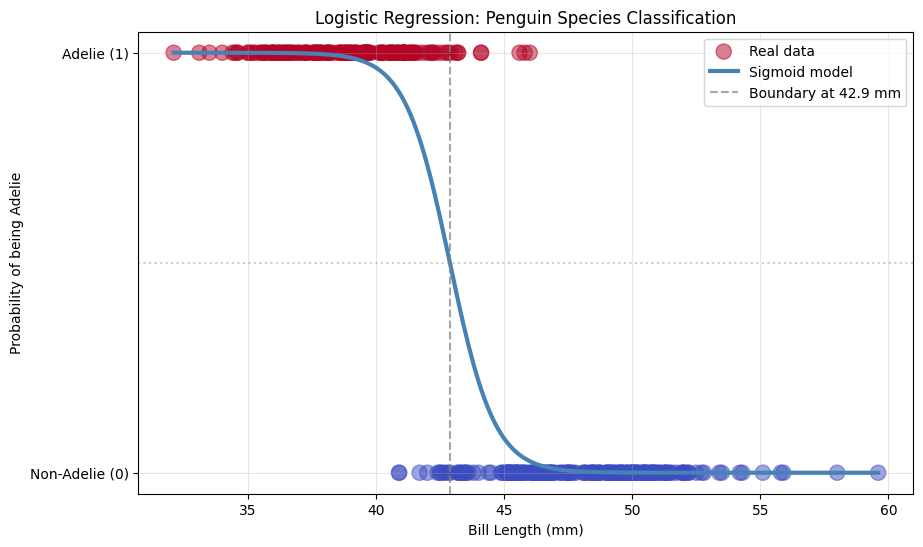

In [112]:

# Plot
x = df_clean["bill_length_mm"]

plt.figure(figsize=(10, 6))

# Real data
plt.scatter(x, y, s=120, alpha=0.5, c=y, cmap="coolwarm", label="Real data")

# Smooth sigmoid curve
x_curve = np.linspace(x.min(), x.max(), 300)
z_curve = weight * x_curve + bias
p_curve = 1 / (1 + np.exp(-z_curve))
plt.plot(x_curve, p_curve, linewidth=3, color="steelblue", label="Sigmoid model")

# Decision threshold
plt.axvline(-bias/weight, linestyle="--", alpha=0.7, color="gray", label=f"Boundary at {-bias/weight:.1f} mm")
plt.axhline(0.5, linestyle=":", alpha=0.4, color="gray")

plt.xlabel("Bill Length (mm)")
plt.ylabel("Probability of being Adelie")
plt.title("Logistic Regression: Penguin Species Classification")
plt.yticks([0, 1], ["Non-Adelie (0)", "Adelie (1)"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()